# Transformer 한국어-영어 번역기 만들기

앞의 NLP02(챗봇)에 이어, 같은 Transformer 구현으로 이번에는 번역기를 만든다.  
데이터는 korean-english-park 병렬 코퍼스(한국어-영어 뉴스 문장쌍 94,123개)이고,  
이번 프로젝트에서 해내야 하는 것은 크게 세 가지다.  

1. SentencePiece 로 한국어/영어 토크나이저를 만들어 전처리하기  
2. Transformer 번역기를 구성해서 정상적으로 학습시키기  
3. 학습된 모델의 Attention Map 을 시각화하고 읽어보기  

진행방식은 NLP02 와 같다.  
아이펠이 준 코드를 그대로 돌려서 내지 않고, 과정에서 발견한 문제와 실험을 그대로 기록한다.  
참고로 아이펠 노드의 NLP03 코드에는 그대로 돌리면 안 돌아가는 곳이 세 군데 있었다  
(SentencePiece 학습 인자 문자열이 깨져 있고, 스케줄러가 optimizer 보다 먼저 선언되어 NameError 가 나고,  
loss 계산에 transpose 가 빠져 shape 에러가 난다).  
각 위치에서 다시 설명한다.

## 차례

1. 모델 구현 (NLP02 에서 만든 것 재사용 + 요약)
2. 데이터 관찰 — 중복이 16%나 있었다
3. 정제와 split — 중복 제거는 split 전에
4. SentencePiece 토크나이저
5. 토큰화와 길이 필터 — subword 의 대가
6. 학습 — 15에폭 실측으로 과소적합 확인 후 본 학습
7. 번역 결과와 정직한 평가
8. Attention Map 시각화
9. 회고


## 1. 모델 구현 — NLP02 에서 만든 공유 구현을 그대로 쓴다

Transformer 구현은 NLP02(챗봇) 노트북에서 만든 것을 그대로 쓴다.  
거기서 아이펠 노드 코드를 베이스로 삼되 네 가지를 고쳤고(스택 끝 final_norm 추가 / sqrt(d_model) 스케일링을  
공유 옵션에서 분리 / 어텐션 확률에 dropout / 마스크 함수의 전역 device 의존 제거),  
누수 테스트를 포함한 검증 다섯 종류를 통과시켰다(스크립트로는 assert 21개). 왜 그렇게 고쳤는지의 실측과 근거는  
NLP02 노트북 1~5절에 있다. 여기서는 코드만 다시 싣고, 이 노트북에서 중요해지는 지점 두 가지만 짚는다.  

첫째, 마스크 규약. 구현마다 정반대라서 섞으면 에러 없이 조용히 망가진다.  

```
PAD = 0, BOS = 1, EOS = 2, UNK = 3     (SentencePiece 학습 때도 이 규약으로 박는다)  
마스크 값 1 = 가린다  
마스킹 = 점수 + (mask * -1e9)           (-inf 는 전부 가려진 행에서 softmax 가 nan)  
```

-1e9 를 쓰는 이유를 이번에 제대로 이해했다.  
-inf 로 마스킹하면 전부 가려진 행(빈 문장 같은 병적인 경우)에서  
softmax 가 0/0 = nan 이 되는데, nan 은 0을 곱해도 nan 이라서 어텐션의 확률 0 곱하기도,  
loss 의 패딩 마스크 곱하기도 다 뚫고 퍼진다.  
한 번 생기면 backward 를 타고 한 스텝 만에 모델 전체 가중치가 nan 이 되어 되돌릴 수 없다.  
-1e9 는 유한해서 정상 행에서는 확률을 정확히 0으로 만들고(e^-10억은 언더플로로 0),  
병적인 행에서도 nan 대신 무해한 균등분포를 남긴다.  

둘째, 어텐션 가중치의 반환. 이 구현은 매 레이어의 어텐션 확률맵을 리스트로 모아 반환하는데(아이펠 인터페이스),  
이번 프로젝트의 Attention Map 시각화가 바로 이걸 쓴다.  
어텐션 확률에 dropout 을 걸 때 V 에 곱하는 쪽에만 걸고 반환값은 dropout 전 값으로 둔 것도 그래서다.  
시각화는 eval 모드라 dropout 이 어차피 꺼지니 그림에 구멍이 뚫릴 일은 없지만,  
반환값의 의미가 모드에 따라 달라지면 안 되니 규약 자체를 "진짜 분포"로 못박아 둔 것이다 (8절에서 다시 짚는다).  


In [1]:
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# 특수 토큰 인덱스. NLP03 SentencePiece 지시문 값으로 두 프로젝트 다 통일한다.
# cpm0722는 pad_idx=1 이라서 그대로 베끼면 <BOS>가 패딩 취급된다 -> 0으로 못박음.
PAD = 0
BOS = 1
EOS = 2
UNK = 3

### 1-1. Positional Encoding

In [2]:
def positional_encoding(pos, d_model):
    """sin/cos 위치 인코딩 표를 만든다. 반환 shape = [pos, d_model]"""

    # 위치 position, 차원 i 에서의 각도. 짝수/홀수 차원이 같은 주기를 쓰도록 i//2
    def cal_angle(position, i):
        return position / np.power(10000, (2 * (i // 2)) / np.float32(d_model))

    # 한 위치에 대해 d_model개 차원의 각도 벡터를 만든다
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]
    # sinusoid는 사인(Sine) 또는 코사인(Cosine) 함수 형태의 주기적 파형(정현파)를 뜻한다.
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    # 짝수 차원에는 sin, 홀수 차원에는 cos
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table
    # 참고: jaygala24는 이 표를 self.pe[:x.size(0)] 로 잘라서 "위치"가 아니라
    # "배치 번호"에 PE를 붙이는 버그가 있었다. 나는 아이펠 방식(seq_len으로 슬라이스)을 쓴다.

### 1-2. 마스크 생성

마스크는 딱 두 종류다. 배치를 직사각형으로 만들려고 채운 PAD 를 못 보게 하는 패딩 마스크(문장마다 경계가 다르다),  
그리고 훈련 때 정답 문장이 통째로 입력되니까 미래 토큰을 못 보게 하는 룩어헤드 마스크(위치끼리의 관계라 배치 전체가 같은 계단 하나를 쓴다).  
디코더는 둘 다 필요해서 torch.max(= OR)로 겹친다.

In [3]:
def generate_padding_mask(seq):
    """
    seq: [batch, seq_len] 토큰 ID 텐서
    반환: [batch, 1, 1, seq_len]. PAD(0) 자리가 1, 진짜 토큰 자리가 0.

    패딩은 "열(보이는 놈)"만의 문제라서 행 정보가 필요 없다. 그래서 한 줄짜리
    [.., 1, seq_len] 로 만들어두면, 나중에 브로드캐스팅이 모든 행에 복사해준다.
    """
    # (seq == PAD)는 불리언 -> float()로 1.0/0.0 변환. 차원 2개 추가(head, query 자리)
    return (seq == PAD).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size, device=None):
    """
    size: 타겟 시퀀스 길이
    반환: [size, size]. i번째 행 = i번째 토큰이 못 보는 곳(미래 j>i)이 1.

    미래 차단은 (행=보는 놈, 열=보이는 놈) 둘 다 봐야 판정되니까 태생부터 2차원 표다.
    """
    # triu(diagonal=1) = 주대각선 위쪽만 1 -> 정확히 "j > i (미래)" 자리
    return torch.triu(torch.ones(size, size, device=device), diagonal=1)


def generate_masks(src, tgt):
    """
    src, tgt: [batch, seq_len]
    반환 3개:
      enc_mask     [batch, 1, 1, src_len]  인코더 self-attention용 (src 패딩만)
      dec_enc_mask [batch, 1, 1, src_len]  디코더 cross-attention용 (역시 src 패딩만.
                                           K, V가 인코더 출력이라 가릴 건 src 패딩뿐이다)
      dec_mask     [batch, 1, tgt_len, tgt_len]  디코더 self-attention용 (패딩 OR 미래)
    """
    # 1) 인코더 입력용 패딩 마스크. 인코더에는 룩어헤드를 안 겹친다 —
    #    소스 문장은 추론 때도 처음부터 통째로 주어지니까 미래를 가릴 이유가 없다.
    enc_mask = generate_padding_mask(src)

    # 2) 디코더가 인코더 출력을 볼 때(cross-attention)도 src 패딩만 가리면 된다
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 self-attention: 룩어헤드(미래 차단)와 tgt 패딩을 겹친다
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1], device=tgt.device)
    dec_tgt_padding_mask = generate_padding_mask(tgt)          # [batch, 1, 1, tgt_len]
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, tgt_len, tgt_len]

    # 1 = "가린다" 규약에서는 "하나라도 가리자고 하면 가려야" 하니까 OR가 필요하고,
    # 0/1 텐서에서 원소별 max가 정확히 OR다. (하버드는 1="살린다"라서 반대로 & 를 쓴다)
    # 패딩 마스크의 한 줄 [.., 1, tgt_len] 은 브로드캐스팅으로 tgt_len개 행에 복사돼 겹쳐진다.
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

### 1-3. Multi-Head Attention (어텐션 확률 dropout 은 V 곱하기 직전에만, 반환은 dropout 전)

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.0):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 head 수로 나눈 만큼이 각 head가 담당하는 차원
        self.depth = d_model // num_heads

        # Q, K, V를 만드는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # head들을 합친 뒤 마지막 선형 변환
        self.linear = nn.Linear(d_model, d_model)

        # 어텐션 확률에 걸 dropout (수정 3)
        self.attn_dropout = nn.Dropout(dropout)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch, num_heads, seq_len, depth]
        mask:    1 = 가린다 규약의 마스크 (브로드캐스팅 가능한 shape)
        """
        d_k = Q.size(-1)
        # Q와 K의 내적 -> [batch, num_heads, q_len, k_len]
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # sqrt(d_k)로 스케일링. 안 하면 내적 값이 커져 softmax가 한쪽에 몰린다
        scaled_qk = QK / math.sqrt(d_k)

        # 마스크 자리(1)에 -1e9를 더해 softmax 확률을 0 근처로 보낸다.
        # -inf가 아니라 -1e9인 이유: 전부 패딩인 행에서 -inf는 softmax가 0/0이 돼
        # nan을 뱉지만, -1e9면 그냥 균등분포가 나오고 넘어간다 (그 행은 loss에서 빠져 무해)
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)

        # dropout은 V를 곱하기 직전의 확률에만 건다 (수정 3).
        # 반환하는 attentions는 dropout "전" 값 — 시각화에 쓸 거라서
        # 반환값은 '진짜 확률분포'라는 규약을 지킨다 (하버드/cpm0722도 같은 위치에 건다)
        out = torch.matmul(self.attn_dropout(attentions), V)

        return out, attentions

    def split_heads(self, x):
        """[batch, seq_len, d_model] -> [batch, num_heads, seq_len, depth]"""
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """[batch, num_heads, seq_len, depth] -> [batch, seq_len, d_model]"""
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        # 선형 변환으로 Q, K, V를 만든다
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        # 멀티헤드로 쪼갠다
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # 스케일드 닷 프로덕트 어텐션
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head들을 다시 합치고 마지막 선형
        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

### 1-4. Position-wise Feed Forward

In [5]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        # d_model -> d_ff -> d_model. 토큰 위치마다 독립적으로 적용되는 2층 MLP
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 넓혔다가
        out = self.fc2(out)           # 다시 좁힌다
        return out

### 1-5. Encoder / Decoder 레이어 (Pre-LN)

In [6]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # Pre-LN: 서브레이어에 들어가기 "전"에 정규화한다
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)                                  # 입력만 정규화 (Pre-LN)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual                                  # 정규화 안 된 원본을 더한다

        # Position-wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, enc_attn


class DecoderLayer(nn.Module):
    # 원본은 마지막 두 인자 이름이 (dec_enc_mask, padding_mask)였는데, padding_mask
    # 자리에 실제로는 룩어헤드+패딩이 겹쳐진 dec_mask가 들어온다. 이름이 실체를
    # 속이고 있어서 (내가 처음에 버그로 오독했다) 하는 일 그대로 바꿔 달았다:
    # self_attn_mask = 자기 문장용 (미래+패딩), cross_attn_mask = 인코더 출력용 (src 패딩).
    # 인자 순서는 원본과 동일해서 노드의 호출 코드와 그대로 호환된다.
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        # 참고: jaygala24는 norm 하나를 두 자리에 재사용하는 버그가 있었다.
        # 서브레이어 셋이 각자 gamma/beta를 가져야 하므로 셋 다 따로 만든다.

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, cross_attn_mask, self_attn_mask):
        # 1) Masked self-attention: 자기 문장을 보되 미래와 패딩은 가린다
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=self_attn_mask)
        out = self.do(out)
        out = out + residual

        # 2) Cross-attention: Q는 디코더, K/V는 인코더 출력. src 패딩만 가린다
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=cross_attn_mask)
        out = self.do(out)
        out = out + residual

        # 3) Feed Forward
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

### 1-6. Encoder / Decoder 스택 (끝에 final_norm, 어텐션은 전 레이어 리스트로 반환)

In [7]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)  # 수정 (1): Pre-LN 필수 부품

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for layer in self.enc_layers:
            out, enc_attn = layer(out, mask)
            # 전 레이어의 어텐션을 모아 반환한다 — NLP03 루브릭이 Attention Map
            # 시각화를 요구하고, 노드의 visualize_attention()이 전 레이어를 그린다
            enc_attns.append(enc_attn)
        out = self.final_norm(out)  # 스택 끝 정규화 (수정 1)
        return out, enc_attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)  # 수정 (1): Encoder와 동일

    def forward(self, x, enc_out, cross_attn_mask, self_attn_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for layer in self.dec_layers:
            out, dec_attn, dec_enc_attn = layer(out, enc_out, cross_attn_mask, self_attn_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        out = self.final_norm(out)  # 스택 끝 정규화 (수정 1)
        return out, dec_attns, dec_enc_attns

### 1-7. Transformer 본체

NLP02(챗봇)와 다른 설정 하나가 여기 있다. 챗봇은 질문도 답변도 한국어라 임베딩을   
공유했지만(shared_emb=True), 번역기는 소스가 한국어 사전, 타겟이 영어 사전이라  
임베딩을 공유할 수 없다(shared_emb=False). 디코더 임베딩과 출력층의 공유(shared_fc)는  
둘 다 영어 사전이므로 유지한다.


In [8]:
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # 스케일링에 쓰려고 float으로 저장
        self.d_model = float(d_model)

        # 임베딩. padding_idx=PAD 로 패딩 토큰의 임베딩 벡터를 0으로 고정하고
        # gradient도 안 흐르게 한다 (jaygala24에서 가져옴). 어차피 마스크가 가려주지만
        # 패딩 벡터가 학습으로 흔들릴 이유가 없다.
        # shared_emb=True면 인코더/디코더가 임베딩 표 하나를 같이 쓴다.
        # NLP02(한국어->한국어)는 True — 질문도 답변도 한국어라 사전이 같아 표 하나를 같이 쓴다.
        # 표 크기는 7,836(mecab 사전) x 512 = 약 401만 파라미터. 공유하면 같은 단어의 경험이
        # 한 벡터에 쌓이지만, 8절 실측으로는 val 에 중립이었다. 확실한 이득은 401만 절약 (4-7절).
        # NLP03(한국어->영어)은 사전이 달라서 False.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD)

        # 위치 인코딩 표. 학습 파라미터가 아니라 고정값이므로 buffer로 등록
        pos_encoding_np = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        # 마지막 출력층. shared_fc=True면 디코더 임베딩과 weight를 공유한다
        # (임베딩 = "단어 -> 벡터", 출력층 = "벡터 -> 단어" 라서 같은 표를 양방향으로 쓰는 것)
        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.shared_fc = shared_fc
        if shared_fc:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어, x: [batch, seq_len] 토큰 인덱스
        반환: [batch, seq_len, d_model]
        """
        seq_len = x.size(1)
        out = emb(x)

        # 수정 (2): 원본은 이 스케일링이 if self.shared_fc: 안에 있었다.
        # 논문(3.4절)은 공유 여부와 무관하게 항상 sqrt(d_model)을 곱한다.
        # 원본대로면 shared_fc=False 실험에서 입력 스케일이 22.6배 달라져서,
        # "공유의 효과"와 "스케일의 효과"가 뒤섞여 비교 실험이 성립하지 않는다.
        out = out * math.sqrt(self.d_model)

        # 위치 인코딩을 seq_len 만큼 잘라 더한다 (표 [pos_len, d_model] -> [1, seq_len, d_model])
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch, src_len], dec_in: [batch, tgt_len]
        반환: logits [batch, tgt_len, tgt_vocab], + 전 레이어 어텐션 리스트 3개
        """
        # 임베딩 + 위치 인코딩
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # 인코더 -> 디코더 순서로 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

### 1-8. Noam 스케줄러와 마스킹된 loss

아이펠 NLP03 노드 노트북에는 여기 함정이 둘 있었다. 스케줄러 셀이 optimizer 를 참조하는데  
optimizer 선언 셀보다 앞에 있어서 순서대로 실행하면 NameError 가 나고,  
loss 계산에는 pred.transpose(1, 2) 가 없어서 shape 에러가 난다  
(파이토치 CrossEntropyLoss 는 클래스 차원이 두 번째여야 한다).   
아래는 그걸 고친 버전이다.


In [9]:
class NoamScheduler:
    def __init__(self, d_model, warmup_steps=4000, factor=1.0):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.factor = factor

    def __call__(self, step):
        # step 0이면 0**-0.5 = 무한대가 되므로 1부터 시작하게 방어
        step = max(1.0, float(step))
        arg1 = step ** -0.5                          # warmup 이후: 1/sqrt(step)로 감소
        arg2 = step * (self.warmup_steps ** -1.5)    # warmup 동안: 선형 증가
        return self.factor * (self.d_model ** -0.5) * min(arg1, arg2)

In [10]:
# reduction='none' 이라 토큰마다 loss가 따로 나온다. 그래야 패딩 자리만 골라 뺄 수 있다
loss_object = nn.CrossEntropyLoss(reduction='none')


def loss_function(real, pred):
    """
    real: [batch, tgt_len] 정답 토큰, pred: [batch, tgt_len, vocab] 로짓
    """
    # 패딩(0)이 아닌 자리만 1인 마스크
    mask = (real != PAD).float()
    # CrossEntropyLoss는 클래스 차원이 두 번째여야 한다: (batch, vocab, tgt_len).
    # 이 transpose를 빼먹으면 shape 에러가 난다 (아이펠 NLP03 노트북 코드에 없던 것)
    loss_ = loss_object(pred.transpose(1, 2), real)
    # 패딩 자리 loss를 0으로 만들고, 남은 합을 "진짜 토큰 개수"로 나눈다
    # (전체 길이로 나누면 패딩이 많은 배치일수록 loss가 부당하게 작아진다)
    return (loss_ * mask).sum() / mask.sum()

### 1-9. 구현이 맞는지 확인 — 돌아가는 것과 맞는 것은 다르다

NLP02 에서 만든 검증 중 이 노트북에서도 핵심인 두 개를 다시 돌려 둔다.  
특히 누수 테스트가 중요하다.  
causal mask 가 뚫려 있으면 모델이 정답을 미리 보면서 학습하니까 loss 는 예쁘게 떨어지는데 생성물은 쓰레기가 된다.  
val loss 로도 못 잡는다  
— val 평가도 teacher forcing 이라 정답 문장이 입력에 통째로 들어가서, val 에서도 컨닝이 되기 때문이다.  
그래서 loss 가 아니라 구조 자체를 찌른다: 미래 토큰만 바꿔서 forward 를 두 번 돌리고,  
과거 위치의 logits 가 변하는지 본다. 과거는 그대로 두고 미래만 바꿨으니, 결과가 흔들리면 범인은 미래 참조뿐이다.  

In [11]:
# 검증용 작은 모델 (구조 확인이 목적이라 크기는 작아도 된다)
torch.manual_seed(42)
test_model = Transformer(2, 64, 4, 128, 50, 60, 40, dropout=0.1,
                         shared_fc=True, shared_emb=False)
test_model.eval()   # dropout 을 꺼야 결정론적 비교가 된다

src = torch.randint(4, 50, (3, 10)); src[:, -3:] = PAD   # 소스 끝 3자리 패딩
tgt = torch.randint(4, 60, (3, 8)); tgt[:, -2:] = PAD    # 타겟 끝 2자리 패딩

# 1) 누수 테스트: 미래 토큰만 바꿔 forward 두 번 -> 과거 logits 는 불변이어야 한다
tgt2 = tgt.clone(); tgt2[:, 3:] = 5
em, dem, dm = generate_masks(src, tgt)
em2, dem2, dm2 = generate_masks(src, tgt2)
with torch.no_grad():
    out1, enc_attns, _, _ = test_model(src, tgt, em, dem, dm)
    out2, _, _, _ = test_model(src, tgt2, em2, dem2, dm2)
assert torch.allclose(out1[:, :3], out2[:, :3], atol=1e-5), "누수! causal mask 가 뚫렸다"
assert not torch.allclose(out1[:, 3:], out2[:, 3:], atol=1e-5)  # 미래 쪽은 달라져야 정상
print("누수 테스트 통과: 미래를 바꿔도 과거 예측 불변, max_diff =",
      (out1[:, :3] - out2[:, :3]).abs().max().item())

# 2) 패딩 마스크: 패딩 열의 어텐션 확률이 0인가 + 전부 패딩인 행에서도 nan 이 없는가
pad_prob = enc_attns[-1][:, :, :, -3:].max().item()
assert pad_prob < 1e-6, f"패딩에 어텐션이 샌다: {pad_prob}"
src_allpad = src.clone(); src_allpad[0, :] = PAD
em, dem, dm = generate_masks(src_allpad, tgt)
with torch.no_grad():
    lg, _, _, _ = test_model(src_allpad, tgt, em, dem, dm)
assert not torch.isnan(lg).any(), "-inf 였다면 여기서 nan 이 났을 것"
print(f"패딩 마스크 통과: 패딩 확률 max = {pad_prob:.1e}, 전부 패딩 행에서도 nan 없음")


누수 테스트 통과: 미래를 바꿔도 과거 예측 불변, max_diff = 0.0
패딩 마스크 통과: 패딩 확률 max = 0.0e+00, 전부 패딩 행에서도 nan 없음


## 2. 데이터 관찰 — 중복이 16%나 있었다

korean-english-park 은 뉴스 기사에서 만든 한국어-영어 병렬 코퍼스다.  
train 파일이 .ko 와 .en 두 개로 나뉘어 있고 같은 줄 번호끼리 번역 쌍이다.  
바로 토크나이저부터 만들지 않고, 데이터가 실제로 어떻게 생겼는지부터 쟀다.  
NLP02 에서도 그랬지만 데이터를 재보기 전의 감은 자주 틀린다.

In [12]:
import collections

import numpy as np

DATA = "/home/gmw/Documents/AIFFEL_Work/_scratch/04_NLP/_shared/data"

with open(f"{DATA}/korean-english-park.train.ko", encoding="utf-8") as f:
    raw_ko = [l.strip() for l in f]
with open(f"{DATA}/korean-english-park.train.en", encoding="utf-8") as f:
    raw_en = [l.strip() for l in f]

print(f"줄 수: ko {len(raw_ko):,} / en {len(raw_en):,}")
print(f"빈 줄: ko {sum(1 for s in raw_ko if not s)}, en {sum(1 for s in raw_en if not s)}")

# 같은 줄끼리 쌍으로 묶어 중복을 잰다
raw_pairs = list(zip(raw_ko, raw_en))
n_uniq = len(set(raw_pairs))
print(f"고유 쌍: {n_uniq:,}  (완전 중복이 {len(raw_pairs) - n_uniq:,}쌍 = {(len(raw_pairs)-n_uniq)/len(raw_pairs)*100:.0f}%)")

# 가장 많이 반복된 쌍 3개
for (k, e), c in collections.Counter(raw_pairs).most_common(3):
    print(f"  {c}번 반복: {k[:30]} || {e[:30]}")

# 같은 한국어 문장에 영어 번역이 여러 개 달린 경우 (일대다)
ko2en = collections.defaultdict(set)
for k, e in raw_pairs:
    ko2en[k].add(e)
print(f"같은 ko 에 en 여러 개: {sum(1 for v in ko2en.values() if len(v) > 1):,}건")

# 길이 분포 (공백 단어 기준 — 아직 토크나이저 전이니 대략치)
for name, sents in [("ko", raw_ko), ("en", raw_en)]:
    arr = np.array([len(s.split()) for s in sents])
    print(f"{name} 단어수: 중앙값 {np.median(arr):.0f} / 95% {np.percentile(arr, 95):.0f} / 최대 {arr.max()}")


줄 수: ko 94,123 / en 94,123
빈 줄: ko 0, en 0
고유 쌍: 78,941  (완전 중복이 15,182쌍 = 16%)
  554번 반복: 홍콩 닭장 아파트 생활 || Living in a cage in Hong Kong
  554번 반복: 잭슨 소장품 경매 장갑 최고가 낙... || Glove, other Michael Jackson i
  554번 반복: 수잔 보일 데뷔 음반 예약주문 1... || Susan Boyle's debut CD sets Am


같은 ko 에 en 여러 개: 431건


ko 단어수: 중앙값 14 / 95% 26 / 최대 82
en 단어수: 중앙값 20 / 95% 39 / 최대 90


재보니 심각하다.  
94,123쌍 중 완전 중복이 15,182쌍(16%)이고, 심한 것은 같은 문장 쌍이  
554번 들어 있다 (크롤링 잔해로 보인다).  
6쌍 중 1쌍은 복사본인 셈이다.  
그리고 같은 한국어 문장에 서로 다른 영어 번역이 달린 일대다도 431건 있다.  

## 3. 정제와 split — 중복 제거는 split 전에

중복을 안 지우고 학습하면 두 가지가 망가진다.

1. 554개짜리 복사본이 train 과 val 양쪽에 필연적으로 들어간다. 그러면 val 이 "train 에서 통째로 외운 문장"을 채점하게 되어 val loss 가 거짓으로 좋아진다.  
   NLP02 에서 "증강은 반드시 split 뒤에" 였던 것과 정확히 같은 원리인데 방향만 반대다.  
   쌍둥이를 만드는 작업(증강)은 split 뒤에, 쌍둥이를 없애는 작업(중복 제거)은 split 전에.  
2. train 안에서만 봐도 그 문장에 가중치 554배를 주는 셈이라, 모델 용량이 몇 문장 암기에 낭비된다.  

그래서 순서는 중복 제거 -> 정제 -> 셔플 -> split 이다. split 뒤에 한 가지 더 점검했다.  
일대다 431건 때문에 "같은 한국어 문장인데 영어만 다른 쌍"이 train 과 val 에 갈라져 들어갈 수 있다.  
이것도 부드러운 누수라서(문제를 이미 봤고 답만 다른 시험), val 쪽에 걸린 것들을 통째로 train 으로 옮겨 val 을 순수하게 만들었다.  

정제 함수는 지시 조건 그대로다: 소문자로 변환하고, 알파벳/문장부호/한글만 남기고,  
문장부호 양옆에 공백을 넣고, 앞뒤 공백을 제거한다. 두 가지는 내 판단을 보탰다.  

- **숫자는 남겼다.** 조건 목록에 숫자가 없지만, 뉴스 데이터라 숫자를 지우면  
  "2005년", "10명" 같은 정보가 통째로 사라진다. 지우고 학습하면 숫자 든 문장의 번역 쌍이 다 어긋난다.  
- **정제 뒤 중복 제거를 한 번 더 했다.** 소문자화 때문에 대소문자만 다르던 쌍이 같아지고, 특수문자 제거로 빈 문장이 생길 수 있어서다  
  (실제로 빈 문장 11개, 새 중복 10쌍이 나왔다).  


In [13]:
import random
import re


def clean(sent):
    # 지시 조건: 소문자화 / 알파벳·문장부호·한글만 / 문장부호 양옆 공백 / 앞뒤 공백 제거
    # (숫자는 조건에 없지만 뉴스 데이터라 지우면 정보가 사라져 남겼다)
    sent = sent.lower()
    sent = re.sub(r"[^a-z0-9가-힣?.!,\s]", " ", sent)
    sent = re.sub(r"([?.!,])", r" \1 ", sent)
    sent = re.sub(r"\s+", " ", sent).strip()
    return sent


# 1) 완전 중복 쌍 제거 (등장 순서 보존)
seen, pairs = set(), []
for p in raw_pairs:
    if p not in seen:
        seen.add(p)
        pairs.append(p)
print(f"중복 제거: {len(raw_pairs):,} -> {len(pairs):,}쌍")

# 2) 정제 -> 빈 문장 제거 -> 정제로 새로 생긴 중복 재제거
pairs = [(clean(k), clean(e)) for k, e in pairs]
pairs = [(k, e) for k, e in pairs if k and e]
seen2, dedup2 = set(), []
for p in pairs:
    if p not in seen2:
        seen2.add(p)
        dedup2.append(p)
print(f"정제 후: 빈 문장/재중복 정리 -> {len(dedup2):,}쌍")
pairs = dedup2

# 3) 셔플 후 95:5 split (seed 고정)
random.seed(42)
random.shuffle(pairs)
n_val = int(len(pairs) * 0.05)
val_pairs, train_pairs = pairs[:n_val], pairs[n_val:]
print(f"split: train {len(train_pairs):,} / val {len(val_pairs):,}")

# 4) 소프트 누수 점검: val 의 ko 문장이 train 에도 있으면 train 으로 옮긴다
train_ko_set = set(k for k, _ in train_pairs)
crossers = [i for i, (k, _) in enumerate(val_pairs) if k in train_ko_set]
moved = [val_pairs[i] for i in crossers]
val_pairs = [p for i, p in enumerate(val_pairs) if i not in set(crossers)]
train_pairs.extend(moved)
print(f"val 의 ko 가 train 에도 등장: {len(moved)}건 -> train 으로 이동")
print(f"최종: train {len(train_pairs):,} / val {len(val_pairs):,}")


중복 제거: 94,123 -> 78,941쌍


정제 후: 빈 문장/재중복 정리 -> 78,920쌍
split: train 74,974 / val 3,946
val 의 ko 가 train 에도 등장: 103건 -> train 으로 이동
최종: train 75,077 / val 3,843


## 4. SentencePiece 토크나이저

NLP02 챗봇에서는 한국어를 mecab 형태소로 자르고 그 위에 사전을 직접 만들었다.  
이번에는 한국어와 영어 두 언어를 다뤄야 해서 그 방식이 안 맞는다. 지시대로 SentencePiece 를 쓰는데,   
써보니 이 도구의 요점은 두 가지였다.

첫째, 사전 토큰화가 필요 없다.  
공백조차 하나의 문자(▁)로 취급해서 문장을 통짜 문자열로 보고   
그 위에서 바로 subword 조각 사전을 학습한다. 그래서 언어를 안 가리고  
(한국어엔 mecab, 영어엔 split 하던 것을 한 도구로 통일), 복원이 무손실이다  
(조각을 이어붙이고 ▁를 공백으로 되돌리면 원문이 정확히 나온다. mecab 은 띄어쓰기가  
뭉개져서 되돌릴 수 없었다).  

둘째, 특수 토큰 규약이 토크나이저 학습 인자에서 박힌다. PAD=0, BOS=1, EOS=2, UNK=3 을  
여기서 지정하면 이후 파이프라인 전체가 이 규약 위에서 돈다.  

사전(vocab)은 "단어 사전"이 아니라 크기가 제각각인 레고 상자다. 자주 나온 단어는  
통짜 조각으로, 덜 흔한 단어는 중간 조각으로, 그리고 학습 데이터에 나온 글자 하나하나도  
최소 조각으로 들어 있다. 처음 보는 단어는 아는 큰 조각부터 맞춰보다가 안 되면 글자 조각까지 내려가 조립된다.  
그래서 UNK 는 그 글자가 **사전(alphabet)에 못 들었을 때** 나온다.  
"사전에 없다"와 "코퍼스에 없다"는 다른 말인데, 나는 이걸 헷갈려서 아래에서 한 번 걸려 넘어졌다.  

주의할 점 두 가지.  

- 토크나이저도 train 쪽 문장만으로 학습한다. val 문장을 보여주는 것도 미세한 누수다  
  (NLP02 에서 사전을 train 형태소로만 만든 것과 같은 원리).  
- 아이펠 노드의 generate_tokenizer() 는 학습 인자를 문자열로 이어 붙이는데 그 문자열이 깨져 있다.  
  문자열 두 개를 이어 붙이는 자리에 공백이 없어서 `--vocab_size=20000--pad_id==0` 처럼 인자가 붙어버리고, `--pad_id==%d` 로  
  등호가 두 개다. 그대로 쓰면 학습이 안 된다.  
  문자열 조립 대신 파이썬 인자로 넘기면 이런 사고 자체가 없어서 그렇게 바꿨다.  
- 지시문의 `set_encode_extra_options("bos:eos")` (영어 토크나이저가 인코딩 때 BOS/EOS 를 자동으로 붙이는 옵션)는 쓰지 않았다.  
  대신 5절에서 소스/타겟 모두 BOS/EOS 를 직접 붙인다 — 두 언어를 같은 방식으로 다루는 게 실수를 줄여서다.  
  결과 텐서는 동일하다.  

In [14]:
import os

import sentencepiece as spm

WORK = "/home/gmw/Documents/AIFFEL_Work/_scratch/04_NLP/NLP03/build/nb_work"
os.makedirs(WORK, exist_ok=True)

# SentencePiece 는 파일 입력을 받으므로 train 문장을 파일로 쓴다 (val 은 안 보여준다)
with open(f"{WORK}/train.ko", "w", encoding="utf-8") as fk, \
     open(f"{WORK}/train.en", "w", encoding="utf-8") as fe:
    for k, e in train_pairs:
        fk.write(k + "\n")
        fe.write(e + "\n")

# 한국어/영어 각각 vocab 20,000 으로 학습. 특수 토큰 규약을 여기서 박는다
for lang in ["ko", "en"]:
    spm.SentencePieceTrainer.train(
        input=f"{WORK}/train.{lang}",
        model_prefix=f"{WORK}/spm_{lang}",
        vocab_size=20000,
        pad_id=0, bos_id=1, eos_id=2, unk_id=3,   # PAD=0, BOS=1, EOS=2, UNK=3
    )
    print(f"[{lang}] 학습 완료")

sp_ko = spm.SentencePieceProcessor(f"{WORK}/spm_ko.model")
sp_en = spm.SentencePieceProcessor(f"{WORK}/spm_en.model")


[ko] 학습 완료


[en] 학습 완료


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /home/gmw/Documents/AIFFEL_Work/_scratch/04_NLP/NLP03/build/nb_work/train.ko
  input_format: 
  model_prefix: /home/gmw/Documents/AIFFEL_Work/_scratch/04_NLP/NLP03/build/nb_work/spm_ko
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  

In [15]:
# 눈으로 확인 1: 특수 토큰 규약이 진짜 박혔나
for i in range(4):
    print(f"id {i} = {sp_ko.id_to_piece(i)!r} (ko) / {sp_en.id_to_piece(i)!r} (en)")

# 눈으로 확인 2: 조각내기 (▁ 가 원래 공백 자리)
ko_sent = "두 번째 불가리아인 인질에 대한 생존 희망은 점점 희미해지고 있다."
en_sent = "Hopes that a second Bulgarian hostage is still alive are fading."
print("\nko:", sp_ko.encode(ko_sent, out_type=str))
print("en:", sp_en.encode(en_sent, out_type=str))

# 눈으로 확인 3: 무손실 복원
rt = sp_ko.decode(sp_ko.encode(ko_sent))
print("\n복원 == 원문 ?", rt == ko_sent)


id 0 = '<pad>' (ko) / '<pad>' (en)
id 1 = '<s>' (ko) / '<s>' (en)
id 2 = '</s>' (ko) / '</s>' (en)
id 3 = '<unk>' (ko) / '<unk>' (en)

ko: ['▁두', '▁번째', '▁불가리아', '인', '▁인질', '에', '▁대한', '▁생존', '▁희망', '은', '▁점', '점', '▁희미', '해지', '고', '▁있다', '.']
en: ['▁', 'H', 'op', 'es', '▁that', '▁a', '▁second', '▁', 'B', 'ul', 'g', 'arian', '▁hostage', '▁is', '▁still', '▁alive', '▁are', '▁fa', 'd', 'ing', '.']

복원 == 원문 ? True


In [16]:
# 눈으로 확인 4: 처음 보는 단어의 운명 (레고 조립)
for s in ["직박구리가 트랜스포머를 공부한다", "안녕", "눈사람 기호 ☃"]:
    ids = sp_ko.encode(s)
    print(f"{s!r}")
    print(f"  -> {sp_ko.encode(s, out_type=str)}  (UNK {ids.count(3)}개)")


'직박구리가 트랜스포머를 공부한다'
  -> ['▁직', '박', '구', '리', '가', '▁트랜스포머', '를', '▁공부', '한다']  (UNK 0개)
'안녕'
  -> ['▁안', '녕']  (UNK 1개)
'눈사람 기호 ☃'
  -> ['▁눈', '사람', '▁기', '호', '▁', '☃']  (UNK 1개)


'직박구리'는 코퍼스에 없는 단어인데 UNK 없이 글자 조각(직+박+구+리)으로 조립됐고,  
'트랜스포머'는 뉴스에 자주 나왔는지 통짜 한 조각이다. 재밌는 건 '안녕' 쪽이다.  
'녕'이 UNK 로 나온다. 처음엔 "뉴스에 '안녕'으로 시작하는 기사가 없으니 글자 '녕' 자체가 코퍼스에 없구나"라고 읽었는데,  
직접 세어보니 틀렸다. 학습 코퍼스에 '녕'은 **11번** 나온다 ("안녕하세요, AP 라디오 뉴스 존 벨몬트입니다." 같은 문장).  
진짜 이유는 위 학습 로그에 찍혀 있었다: `character_coverage: 0.9995`, `Alphabet size=1191`.  
SentencePiece 는 글자 빈도 상위 99.95%까지만 alphabet 에 넣고 **하위 0.05% 꼬리는 잘라낸다**.  
500만 글자 중 11번이면 딱 그 꼬리다. 그러니 UNK 는 "코퍼스에 없는 글자"가 아니라 **"사전에 못 든 글자"**일 때 나온다.  
UNK 를 보고 코퍼스에 없다고 단정한 게 내 실수였다 — 자른 건 옵션이었다. 눈사람 기호 ☃ 도 마찬가지다. 이 데이터로 만든 번역기가 뉴스 문체  
밖에서는 약할 거라는 예고이기도 하다.  


## 5. 토큰화와 길이 필터 — subword 의 대가

지시문은 "토큰 길이 50 이하"만 쓰라고 한다. 2절에서 잰 공백 단어 수(ko 중앙값 14)만 보면  
50은 아주 널널한 필터로 보인다. 그런데 SentencePiece 토큰으로 다시 재보면  
이야기가 다르다 — 단어를 조각으로 쪼개니 시퀀스가 두 배 가까이 길어진다.  
이게 subword 의 대가다: OOV 를 없애는 대신 시퀀스가 길어진다.  


In [17]:
# train 전체를 인코딩해서 토큰 길이 분포를 잰다
train_ko_ids = sp_ko.encode([k for k, _ in train_pairs])
train_en_ids = sp_en.encode([e for _, e in train_pairs])
val_ko_ids = sp_ko.encode([k for k, _ in val_pairs])
val_en_ids = sp_en.encode([e for _, e in val_pairs])

for name, ids in [("ko", train_ko_ids), ("en", train_en_ids)]:
    arr = np.array([len(x) for x in ids])
    print(f"{name} 토큰수: 중앙값 {np.median(arr):.0f} / 90% {np.percentile(arr, 90):.0f}"
          f" / 95% {np.percentile(arr, 95):.0f} / 최대 {arr.max()}")


ko 토큰수: 중앙값 25 / 90% 41 / 95% 46 / 최대 133
en 토큰수: 중앙값 29 / 90% 47 / 95% 53 / 최대 116


공백 단어로 중앙값 14였던 한국어가 토큰으로는 25다.   
"토큰 50"은 사실 95% 지점 언저리(한국어 46, 영어 53)에 걸리는 필터였다.  
넘치는 문장은 잘라서 쓸 수도 있지만, 번역은 문장 쌍이라 반토막 한국어에 대응하는 온전한 영어 정답이란 게 없다.  
그래서 자르지 않고 버린다.  

거른 다음엔 배치를 만든다. GPU 는 직사각형 행렬만 빨리 다루는데 문장 길이는 제각각이라,  
"전부 PAD 로 채운 판을 만들고 진짜 토큰을 앞에서부터 써넣는" 방식으로 길이를 맞춘다.  
잘라서 맞추는 게 아니라 채워서 맞춘다. 이 PAD 들이 1-2절 패딩 마스크가 가리는 대상이다.  


In [18]:
MAX_TOKENS = 50            # 지시문: 토큰 50 이하 (BOS/EOS 제외 기준)
MAX_LEN = MAX_TOKENS + 2   # BOS + 50 + EOS


def to_tensor(ko_ids, en_ids, name):
    # 양쪽 다 50 이하인 쌍만 통과시키고, BOS/EOS 를 붙여 PAD 판에 써넣는다
    keep = [i for i in range(len(ko_ids))
            if len(ko_ids[i]) <= MAX_TOKENS and len(en_ids[i]) <= MAX_TOKENS]
    src = torch.full((len(keep), MAX_LEN), PAD, dtype=torch.long)
    tgt = torch.full((len(keep), MAX_LEN), PAD, dtype=torch.long)
    for r, i in enumerate(keep):
        s = [BOS] + ko_ids[i] + [EOS]
        t = [BOS] + en_ids[i] + [EOS]
        src[r, :len(s)] = torch.tensor(s)
        tgt[r, :len(t)] = torch.tensor(t)
    dropped = len(ko_ids) - len(keep)
    print(f"[{name}] 길이 필터: {len(ko_ids):,} -> {len(keep):,}쌍 (탈락 {dropped:,} = {dropped/len(ko_ids)*100:.1f}%)")
    return src, tgt


train_src, train_tgt = to_tensor(train_ko_ids, train_en_ids, "train")
val_src, val_tgt = to_tensor(val_ko_ids, val_en_ids, "val")


[train] 길이 필터: 75,077 -> 68,866쌍 (탈락 6,211 = 8.3%)
[val] 길이 필터: 3,843 -> 3,535쌍 (탈락 308 = 8.0%)


## 6. 학습 — 15에폭 실측으로 "얼마나 오래"를 정했다

하이퍼파라미터는 노드 예시 셋(2층, d_model 512, heads 8, d_ff 2048, dropout 0.3,  
warmup 4000, batch 64)에서 출발했고, NLP02 실험에서 몫이 실측된 Label Smoothing 0.1  
(train loss 에만, val 은 순수 CE)을 이어받았다. 문제는 에폭 수였다.  

이 데이터는 챗봇과 규모가 다르다. NLP02 는 에폭당 52초라 실험을 마음껏 돌렸지만,  
여기는 필터 후 68,866쌍에 시퀀스 길이도 52다. 처음(정제 함수를 넣기 전, 69,394쌍) 쟀을 때
스텝당 313ms, 에폭당 5.7분이었고, 실제 본 학습은 에폭당 1077스텝에 5.5분이었다.  
실험 한 번이 시간 단위라 함부로 여러 번 못 돌린다. 그래서 노트북과 같은 코드를  
스크립트로 빼서 15에폭을 먼저 돌려봤다.  

15에폭 결과: best val 5.29 인데 마지막 에폭까지 에폭당 0.04씩 계속 내려가는 중이었다.  
천장에 닿은 게 아니라 계단 중간에서 멈춘 것이다. 생성물도 과소적합의 지문 그대로였다  
— 무슨 문장을 넣어도 "The government has been a new new new new ..." 처럼 흔한 뉴스  
단어의 반복으로 도망갔다 (NLP02 에서 봤던 "저도 좋은 사람이에요" 만능답변의 번역기판).  

그래서 스크립트로 40에폭을 더 돌려봤다. best val 4.72 — 확실히 좋아졌고 번역도  
갈라지기 시작했는데 ("이 영화는 전 세계에서 큰 인기를 얻었다 -> The movie is the  
world's most popular in the world."), 40에폭에도 val 이 에폭당 0.02씩 여전히 하강  
중이었다. 그래서 본 학습은 최대 60에폭으로 잡고, val 기준 best 시점의 파라미터를  
보관하며, val 이 6에폭 연속 개선되지 않으면 조기 종료한다 (정체된 뒤의 에폭은  
시간 낭비 + train 만 내려가는 과적합 구간이니까). (에폭당 약 6분이라 60에폭이면  
6시간 남짓 — 마감 전에 문제가 생겨도 재시도할 수 있는 한도가 이 언저리다.)  

한 가지 정직하게 적어둘 것: 위 15/40에폭 실측은 3절의 정제 함수를 넣기 **전** 데이터로 잰 것이다  
(정제는 실측 후 지시 조건을 다시 확인하며 추가했다). 정제로 데이터가 소폭 달라졌으니(소문자화, 문장부호 분리)  
아래 본 학습의 loss 눈금이 실측치와 정확히 같지는 않을 수 있다. "아직 하강 중이니 더 길게"라는 결론에는 영향이 없다.  


In [19]:
# 모델 준비. 번역기는 사전이 언어별로 달라서 shared_emb=False (1-7절)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

N_LAYERS, D_MODEL, N_HEADS, D_FF = 2, 512, 8, 2048
DROPOUT, LABEL_SMOOTHING, WARMUP, BATCH, EPOCHS = 0.3, 0.1, 4000, 64, 60
VOCAB_KO, VOCAB_EN = sp_ko.get_piece_size(), sp_en.get_piece_size()

model = Transformer(N_LAYERS, D_MODEL, N_HEADS, D_FF,
                    src_vocab_size=VOCAB_KO, tgt_vocab_size=VOCAB_EN, pos_len=MAX_LEN,
                    dropout=DROPOUT, shared_fc=True, shared_emb=False).to(device)
print(f"파라미터 {sum(p.numel() for p in model.parameters())/1e6:.1f}M, device={device}")

# Noam 스케줄 + 논문 5.3절 Adam. ★노드 노트북은 스케줄러가 optimizer 보다 먼저
# 선언되어 있어 NameError 가 난다 — 여기처럼 스케줄러(독립) -> optimizer 순서면 안전
sched = NoamScheduler(D_MODEL, warmup_steps=WARMUP, factor=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=sched(1), betas=(0.9, 0.98), eps=1e-9)

# 라벨 스무딩은 train loss 에만 (NLP02 실험에서 +0.12 실측). val 은 순수 CE 로
# 눈금을 유지해야 실험끼리 비교가 된다
train_loss_object = nn.CrossEntropyLoss(reduction="none", label_smoothing=LABEL_SMOOTHING)

def train_loss_function(real, pred):
    mask = (real != PAD).float()
    loss_ = train_loss_object(pred.transpose(1, 2), real)   # CE 는 (B, V, T) 를 원한다
    return (loss_ * mask).sum() / mask.sum()


파라미터 35.2M, device=cuda


In [20]:
# greedy 번역 함수. 매 에폭 눈으로 확인하는 용도 (loss 만 믿지 않는다)
@torch.no_grad()
def translate(ko_sent, max_len=MAX_LEN, return_attn=False):
    model.eval()
    ko_sent = clean(ko_sent)   # 학습 데이터와 같은 정제를 입력에도 적용해야 분포가 맞는다
    src_ids = [BOS] + sp_ko.encode(ko_sent)[:MAX_TOKENS] + [EOS]
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    dec = torch.tensor([[BOS]], dtype=torch.long, device=device)
    attn_pack = None
    for _ in range(max_len - 1):
        em, dem, dm = generate_masks(src, dec)
        logits, enc_a, dec_a, dec_enc_a = model(src, dec, em, dem, dm)
        nxt = logits[0, -1].argmax().item()
        if nxt == EOS:
            break
        dec = torch.cat([dec, torch.tensor([[nxt]], device=device)], dim=1)
    if return_attn:   # Attention Map 용: src/출력 id 와 cross-attention 확률맵
        attn_pack = (src_ids, dec[0].tolist(), dec_enc_a)
    out = sp_en.decode(dec[0, 1:].tolist())
    return (out, attn_pack) if return_attn else out


# 매 에폭 번역을 찍어볼 예문 = 지시문이 제시한 공식 예문 4개
PROBES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]


In [21]:
# 학습 루프. val 기준 best 파라미터를 메모리에 보관한다 (조기종료 대용)
import copy
import time

n_batches = (len(train_src) + BATCH - 1) // BATCH
history = {"train": [], "val": []}
best_val, best_state, best_epoch = float("inf"), None, 0
PATIENCE = 6          # 조기 종료: val 이 6에폭 연속 안 좋아지면 남은 에폭은 시간 낭비다
stall = 0
step = 0
print(f"에폭당 {n_batches}스텝 x 최대 {EPOCHS}에폭, warmup {WARMUP}, patience {PATIENCE}")

for epoch in range(1, EPOCHS + 1):
    model.train()
    perm = torch.randperm(len(train_src))
    total, t0 = 0.0, time.time()
    for b in range(n_batches):
        idx = perm[b * BATCH:(b + 1) * BATCH]
        src, tgt = train_src[idx].to(device), train_tgt[idx].to(device)
        tgt_in, gold = tgt[:, :-1], tgt[:, 1:]           # teacher forcing 한 칸 밀기
        em, dem, dm = generate_masks(src, tgt_in)
        step += 1
        for g in optimizer.param_groups:                  # Noam: 매 스텝 lr 갱신
            g["lr"] = sched(step)
        optimizer.zero_grad()
        logits, _, _, _ = model(src, tgt_in, em, dem, dm)
        loss = train_loss_function(gold, logits)          # 스무딩은 train 에만
        loss.backward()
        optimizer.step()
        total += loss.item()

    model.eval()
    with torch.no_grad():                                 # val: 순수 CE
        vsum, vb = 0.0, 0
        for b in range(0, len(val_src), BATCH):
            src, tgt = val_src[b:b+BATCH].to(device), val_tgt[b:b+BATCH].to(device)
            tgt_in, gold = tgt[:, :-1], tgt[:, 1:]
            em, dem, dm = generate_masks(src, tgt_in)
            logits, _, _, _ = model(src, tgt_in, em, dem, dm)
            vsum += loss_function(gold, logits).item(); vb += 1
    vloss = vsum / vb
    history["train"].append(total / n_batches); history["val"].append(vloss)

    if vloss < best_val:                                  # val 기준 best 보관
        best_val, best_epoch = vloss, epoch
        best_state = copy.deepcopy(model.state_dict())
        stall = 0
    else:
        stall += 1

    print(f"에폭 {epoch:3d}/{EPOCHS}  train(LS) {total/n_batches:.4f}  val(CE) {vloss:.4f}  ({(time.time()-t0)/60:.1f}분)")
    for q in PROBES:   # 지시: 매 에폭 예문 번역을 생성한다 (loss 만 믿지 않는다)
        print(f"    {q[:24]} -> {translate(q)[:85]}")

    if stall >= PATIENCE:                                 # 조기 종료
        print(f"\n조기 종료: val 이 {PATIENCE}에폭 연속 개선 없음 (best {best_val:.4f}, 에폭 {best_epoch})")
        break

print(f"\n학습 끝. best val {best_val:.4f} (에폭 {best_epoch}) — 이 시점 파라미터로 되돌린다")
model.load_state_dict(best_state)


에폭당 1077스텝 x 최대 60에폭, warmup 4000, patience 6


에폭   1/60  train(LS) 127.4780  val(CE) 13.9256  (5.5분)


    오바마는 대통령이다. -> the the the the the the the the the the the the the the the the the the the the the t


    시민들은 도시 속에 산다. -> the the the the the the the the the the the the the the the the the the the the the t


    커피는 필요 없다. -> the the the the the the the the the the the the the the the the the the the the the t


...

    일곱 명의 사망자가 발생했다. -> at least 40 people were killed .


에폭  60/60  train(LS) 4.8663  val(CE) 4.2492  (5.5분)
    오바마는 대통령이다. -> obama is the president .


    시민들은 도시 속에 산다. -> the city is a small town of the city .
    커피는 필요 없다. -> it s not a lot of your brain .


    일곱 명의 사망자가 발생했다. -> at least 40 people were killed .

학습 끝. best val 4.2249 (에폭 58) — 이 시점 파라미터로 되돌린다


<All keys matched successfully>

/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49845 (

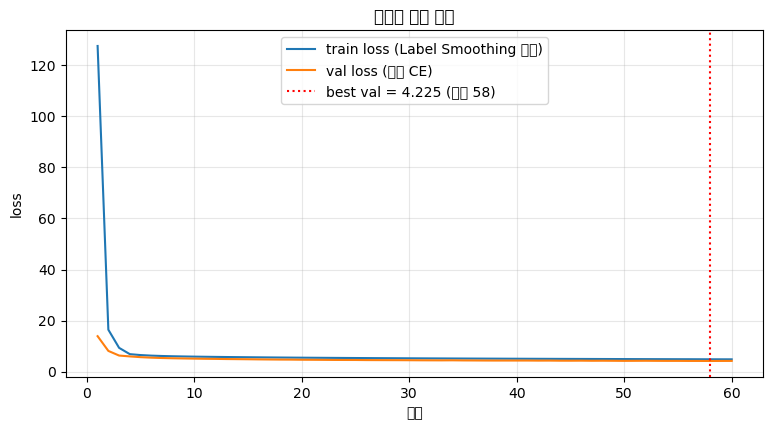

In [22]:
# loss 곡선 — train 은 스무딩 눈금이라 val(순수 CE)과 직접 비교하지 말 것
import matplotlib.pyplot as plt

ep = range(1, len(history["train"]) + 1)
plt.figure(figsize=(9, 4.5))
plt.plot(ep, history["train"], label="train loss (Label Smoothing 눈금)")
plt.plot(ep, history["val"], label="val loss (순수 CE)")
plt.axvline(best_epoch, ls=":", c="red", label=f"best val = {best_val:.3f} (에폭 {best_epoch})")
plt.xlabel("에폭"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=0.3)
plt.title("번역기 학습 곡선")
plt.show()


## 7. 번역 결과와 정직한 평가

best 시점 파라미터로 되돌린 모델로, 먼저 지시된 제출 형식(예문 4개 번역 + 하이퍼파라미터)을 만든다.  
그 다음 학습에 안 쓴 val 문장을 무작위로 뽑아 정답 번역과 나란히 놓는다.


In [23]:
# 지시된 제출 형식: 공식 예문 4개의 번역 + 하이퍼파라미터
print("Translations")
for i, q in enumerate(PROBES, 1):
    print(f"> {i}. {translate(q)}")

print("\nHyperparameters")
for k, v in [("n_layers", N_LAYERS), ("d_model", D_MODEL), ("n_heads", N_HEADS),
             ("d_ff", D_FF), ("dropout", DROPOUT)]:
    print(f"> {k}: {v}")

print("\nTraining Parameters")
print(f"> Warmup Steps: {WARMUP}")
print(f"> Batch Size: {BATCH}")
print(f"> Epoch At: {best_epoch}  (총 {EPOCHS}에폭 중 val 기준 best 시점)")


Translations
> 1. obama is the president .


> 2. the city is a small town of the city .
> 3. it s not a lot of your brain .


> 4. at least 40 people were killed .

Hyperparameters
> n_layers: 2
> d_model: 512
> n_heads: 8
> d_ff: 2048
> dropout: 0.3

Training Parameters
> Warmup Steps: 4000
> Batch Size: 64
> Epoch At: 58  (총 60에폭 중 val 기준 best 시점)


In [24]:
print("[val 무작위 표본 — 정답과 나란히]")
random.seed(7)
for i in random.sample(range(len(val_pairs)), 5):
    k, e = val_pairs[i]
    print(f"  ko: {k[:70]}")
    print(f"  정답: {e[:70]}")
    print(f"  번역: {translate(k)[:70]}\n")


[val 무작위 표본 — 정답과 나란히]
  ko: 불이 번지면서 최소한 한 명이 사망하고 25만 명 정도가 대피했다 .
  정답: at least one person has been killed and some 250 , 000 people evacuate


  번역: at least 25 , 000 people were injured and injured , 000 injured , the 

  ko: 이들 서비스는 한국에서 합법적으로 일하는 외국인들에게는 모두 무료지만 불법노동자들은 자발적으로 한국을 떠나는 경우가 아닌 이상
  정답: but services and facilities at the center will not be available for un


  번역: the korea herald reports south korea will not be used to use the korea

  ko: 일본 출신 시모무라 오사무 교수는 투명한 해파리가 자외선 조명 하에 단백질이 발광하다는 것을 발견해 gfp를 최초로 분리했다 
  정답: osamu shimomura , a japanese citizen , was the first to isolate gfp fr


  번역: the first scientists have called japanese scientists to be named by th

  ko: 경찰은 그에게 30일 징역형을 내리고 차를 압수할 것으로 보인다 .
  정답: she said police wanted the court to jail the man for 30 days and confi


  번역: police said they will be charged within 30 days of his car , and will 

  ko: 힐러리는 앞으로 며칠 동안 지지자와 민주당 지도부를 만나 앞으로의 진로를 결정할 것이라고 밝혔다 .
  정답: clinton said she would meet with supporters and party leaders in the c


  번역: clinton said she would be ready to meet within a week of the next few 



In [25]:
# 수치 평가: val 표본의 BLEU (NLP01 에서 배운 그 지표. 짧은 문장 0점 방지로 smoothing)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

N_EVAL = 300   # 전부 하면 오래 걸려서 앞 300문장만
refs, hyps = [], []
for k, e in val_pairs[:N_EVAL]:
    refs.append([e.split()])
    hyps.append(translate(k).split())

bleu = corpus_bleu(refs, hyps, smoothing_function=SmoothingFunction().method1)
print(f"val {N_EVAL}문장 corpus BLEU: {bleu*100:.2f}")


val 300문장 corpus BLEU: 2.26


val 300문장 corpus BLEU 2.26. 처음엔 당황했다 — NLP01 예습 때 Transformer 로 BLEU 34.89 를 봤었기 때문이다.  
모델은 그때(3층, 임베딩 256)보다 지금(2층 d512, 파라미터 35.2M)이 오히려 크고 데이터도 비슷한 코퍼스인데 점수는 15분의 1이라니.  
그래서 이 숫자를 읽기 전에 그 34.89 의 정체부터 캐봤다. 두 점수는 애초에 같은 시험이 아니었다.  

| | NLP01 예습 (34.89) | NLP03 (2.26) |
|---|---|---|
| 측정 문장 | train-set 300 — 모델이 **본** 문장 | val 300 — 모델이 **안 본** 문장 |
| 모델 상태 | train loss 1.30 (ppl 3.7) 까지 내려간 **암기 상태** | 58에폭까지 val 개선, 59·60만 반등 (암기 진입 전) |
| 정규화 | dropout 0.1, 스무딩 없음 | dropout 0.3 + Label Smoothing 0.1 |
| BLEU smoothing | method4 (더 후함) | method1 |
| 토큰화 | 단어 단위 (mecab + 소문자/구두점 분리) | SentencePiece 20k |

(NLP01 노트북에도 "검증셋을 안 나눠서 절대값은 낙관적"이라고 적어놨었다. 그때는
그 말이 몇 배짜리 낙관인지 몰랐다.)

표의 차이들 중 무엇이 점수를 부풀렸는지 확인하려고, 노트북 밖에서 40에폭 체크포인트
하나를 두고 **잣대만 바꿔가며** 재봤다:

| 측정 (전부 같은 40ep 모델) | BLEU |
|---|---|
| val 300 greedy | 0.75 |
| **train 300 greedy (NLP01 방식 재현)** | **0.64** |
| val beam4 | **1.22** |
| val beam8 | 1.24 |
| (참고) 15에폭 체크포인트, val greedy | 0.29 |

여기서 반전이 나왔다. **train-set 으로 재도 점수가 안 부풀었다** (0.64 — val 과 사실상 같음).  
부풀리는 건 "train-set 측정" 단독이 아니라 **"암기한 모델 + 암기한 문장으로 시험"의 조합**이라는 뜻이다.  
NLP01 예습 모델은 정규화가 약해 훈련 문장을 통째로 외웠고(ppl 3.7 = 다음 단어 후보가 사실상 3.7개), 외운 문장으로 시험을 봤다.  
이번 모델은 dropout 0.3 + LS 0.1 로 눌려서 외운 게 없고, 외운 게 없으면 train-set 시험도 소용이 없다.  
34.89 대 2.26 은 모델 퇴보가 아니라 시험 방식의 차이였다.  

- (사이드 실험 숫자들은 정제 함수를 넣기 전 파이프라인 잣대라 본문의 2.26 과 절대값 직접 비교는 안 된다.  
  같은 실험 안의 상대 비교용. 또 smoothing method4/method1 은 재보니 코퍼스 레벨에선 결과가 같았다 — 300문장 합산 n-gram 매치가 0이 아니면
  smoothing 은 발동하지 않는다. 용의자 하나는 무죄.  
  다만 표의 용의자 중 **토큰화(단어 단위 vs SentencePiece)는 끝내 못 재봤다.** BLEU 는 토큰화에 민감한 지표라
  작은 용의자가 아닌데, 재려면 NLP01 모델을 다시 돌려야 해서 이번엔 미결로 남긴다.)

그럼 2.26 자체는 어떻게 읽나. 세 겹으로 읽었다.

1. **데이터 예산.** 트랜스포머 원논문(base)이 BLEU 27.3 을 만들 때 데이터가 450만 쌍이었다.  
   여기는 68,866쌍 — 1.5%다. 데이터가 이만큼 적다는 사실만으로도 점수가 낮게 나오는 이유는 충분히 설명된다.  
   다만 2.26 이 "이 정도면 정상"인지 "그래도 낮은 편"인지 판정할 잣대는 나에게 없다.  
   같은 데이터, 같은 조건으로 남이 낸 점수를 본 적이 없으니 비교할 대상이 없다.  
   NLP02 때는 "번역이면 두 자릿수도 흔하다"고 예상해 적어두기까지 했는데,  
   그 예상의 근거를 지금 대보라면 못 댄다. 어디선가 본 숫자를 근거 없이 옮겨온 것이었다.  
   내가 실제로 말할 수 있는 건 여기까지다: 내 데이터로 내가 잰 점수는 2.26 이고, 그 숫자는 아래 두 가지로 움직였다.  
2. **에폭.** 에폭이 BLEU 를 실제로 산다: 같은 잣대의 체크포인트끼리 재보니 15에폭  
   0.29 -> 40에폭 0.75 (2.6배)였고, 본 학습 안에서도 에폭 40 val CE 4.39(ppl 81) ->  
   에폭 58 4.22(ppl 68)로 계속 좋아졌다. best 가 58/60 이라는 건 6절의 "40에폭에도 하강 중이니 60"  
   판단이 맞았다는 뜻이고, 동시에 58 이후 꺾였으니 이 세팅의 수렴 지점 언저리에 닿았다는 뜻이다.  
   80~100에폭 연장도 생각해봤지만 곡선이 이미 답을 줬다:  
   개선폭이 에폭 40->50 구간 -0.012/에폭에서 50->58 구간 -0.005/에폭으로 줄었고 59·60은 연속 반등이라,  
   연장해도 patience 6이 에폭 64쯤 끊고 best 는 58 언저리로 돌아올 그림이다.  
   다만 이 곡선은 2~3에폭 반등한 뒤 다시 내려간 전례가 네 번이나 있었다(34 / 39~41 / 46 / 51~52에폭).
   그러니 59·60 반등만으로 58이 진짜 바닥이라고 단정할 수는 없다. 여기서 끊은 진짜 이유는
   기울기가 절반으로 줄었다는 것(수확 체감)과 시간 예산이다 — 감이 아니라 곡선을 보고 답했다는 점은 그대로다.  
   다만 에폭이 못 고치는 병도 봤다 — "일곱 명의 사망자"를 에폭 40에도 58에도 "at least 40 people"로 옮긴다(숫자 환각).  
   이건 학습 부족이 아니라 데이터 부족의 병이고, 에폭 연장은 데이터를 불린 뒤에야 다시 의미가 생긴다.  
3. **디코딩.** greedy 는 매 토큰 1등만 골라서 흔한 구절로 도망간다(위 반복 붕괴).  
   위 표처럼 beam search 만 붙여도 greedy 0.75 -> beam4 1.22 (+63%), beam8 은  
   1.24 로 수확 체감이었다. 재학습 없이 디코딩만 바꿔도 이만큼 번다 — 회고의    
   "Beam Search 가 다음 열쇠"는 이제 주장이 아니라 실측이다.    

결론: BLEU 를 올리는 순서는 (1) 잣대부터 통일하고 (2) 디코딩(beam)과 학습 연장으로  
소폭 벌고 (3) 크게 벌려면 데이터를 불리는 것(AI Hub 병렬 코퍼스 등)이다.  
데이터 1.5% 로 아키텍처만 만져서 두 자릿수를 바라는 건 순서가 틀렸다.  
그리고 NLP01 의 34.89 는 반성문으로 남긴다 — 높은 점수가 나오면 기뻐하기 전에 시험지가 뭐였는지부터 봐야 한다.


## 8. Attention Map 시각화 — 그리는 것보다 읽는 것

번역하면서 수집한 cross-attention(디코더가 인코더를 보는 눈)을 그린다.  
세로축이 모델이 만든 영어 조각, 가로축이 한국어 입력 조각이고, 각 가로줄은 합이 1인 확률분포다 — "이 영어 조각을 뱉을 때 한국어 어디를 봤는가".

1-3절에서 어텐션 확률의 dropout 을 V 곱하기 직전에만 걸고 반환값은 dropout 전으로 둔 규약이 여기서 쓰인다.  
정직하게 말하면, 시각화는 eval 모드라 dropout 이 어차피 꺼져 있어서 반환값을 dropout 후로 뒀더라도  
이 그림에 구멍이 뚫리진 않았을 것이다.  
그래도 반환값의 의미가 모드에 따라 달라지면 안 되니 규약 자체를 "진짜 분포"로 못박아 둔 것이다.  

ko: 두 번째 불가리아인 인질에 대한 생존 희망은 점점 희미해지고 있다.
en: the second hostages have been taken to the second hostages , which have been held in the second day of the second hostages , which they have been taken to be taken to the second hostages .


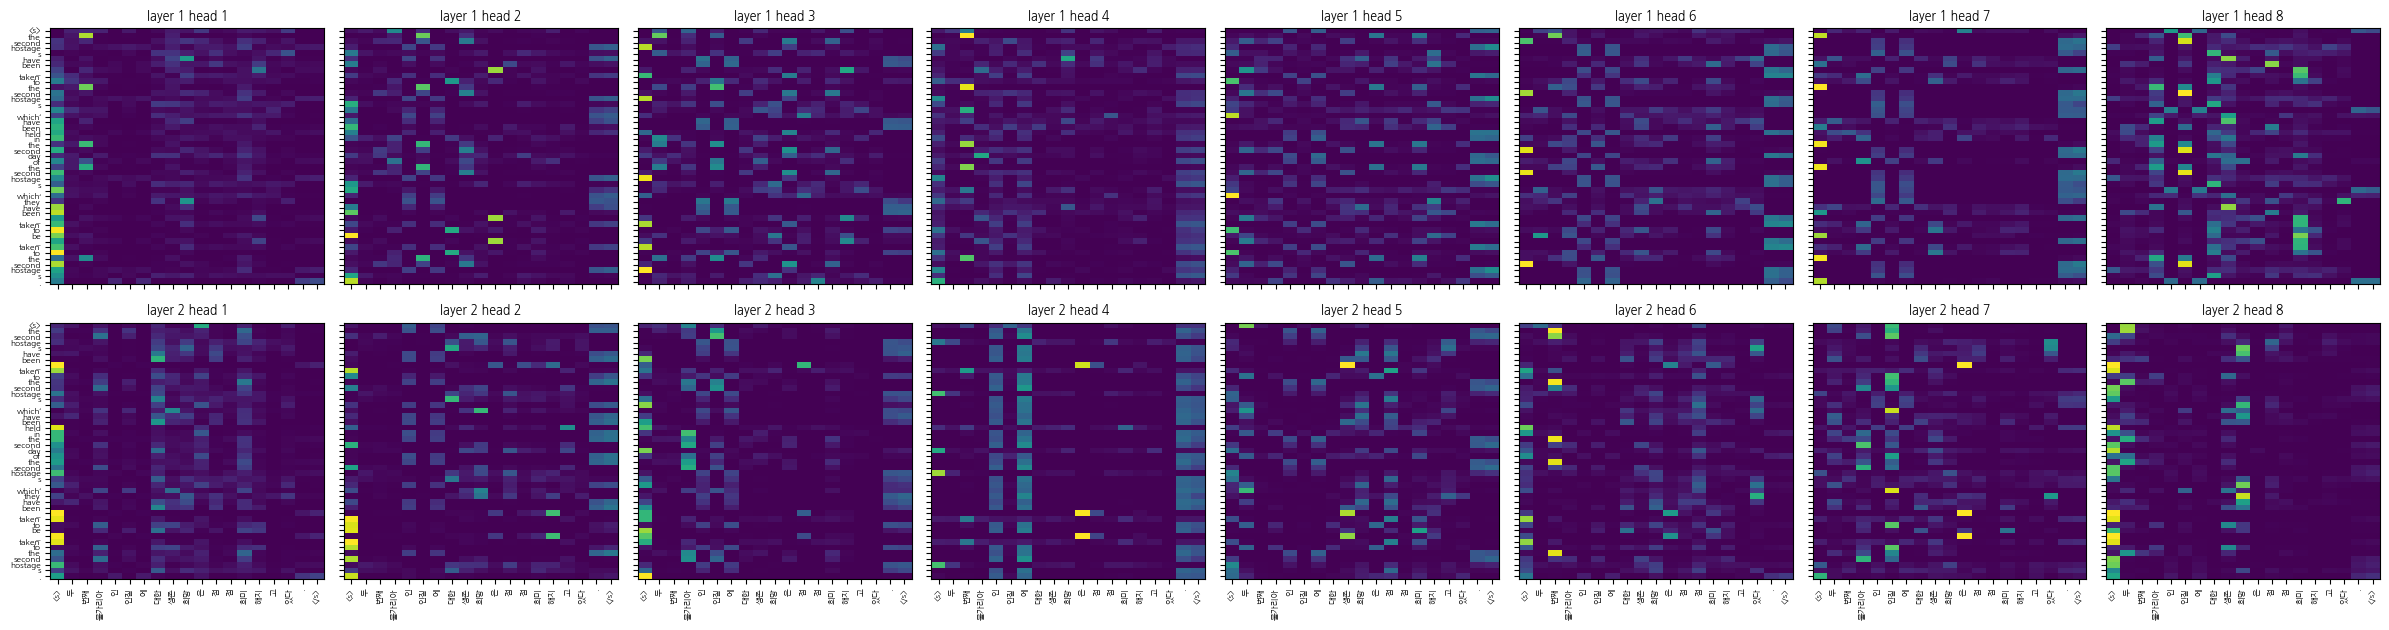

In [26]:
def draw_attention(ko_sent):
    out, (src_ids, out_ids, dec_enc_attns) = translate(ko_sent, return_attn=True)
    ko_pieces = [sp_ko.id_to_piece(i).replace("\u2581", " ").strip() or "_" for i in src_ids]
    en_pieces = [sp_en.id_to_piece(i).replace("\u2581", " ").strip() or "_" for i in out_ids]
    print(f"ko: {ko_sent}")
    print(f"en: {out}")

    fig, axes = plt.subplots(N_LAYERS, N_HEADS, figsize=(3.0 * N_HEADS, 3.2 * N_LAYERS),
                             squeeze=False)
    for li in range(N_LAYERS):
        for hi in range(N_HEADS):
            ax = axes[li][hi]
            ax.imshow(dec_enc_attns[li][0, hi].cpu().numpy(), cmap="viridis", aspect="auto")
            ax.set_title(f"layer {li+1} head {hi+1}", fontsize=9)
            ax.set_xticks(range(len(ko_pieces)))
            ax.set_yticks(range(len(en_pieces)))
            ax.set_xticklabels(ko_pieces if li == N_LAYERS - 1 else [],
                               rotation=90, fontsize=6)
            ax.set_yticklabels(en_pieces if hi == 0 else [], fontsize=6)
    plt.tight_layout()
    plt.show()


# 한글 폰트 (조각 라벨이 한국어다)
import matplotlib.font_manager as fm
for cand in ["NanumGothic", "NanumBarunGothic", "Noto Sans CJK KR"]:
    if any(cand == f.name for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = cand
        break
plt.rcParams["axes.unicode_minus"] = False

draw_attention("두 번째 불가리아인 인질에 대한 생존 희망은 점점 희미해지고 있다.")


ko: 오바마는 대통령이다.
en: obama is the president .


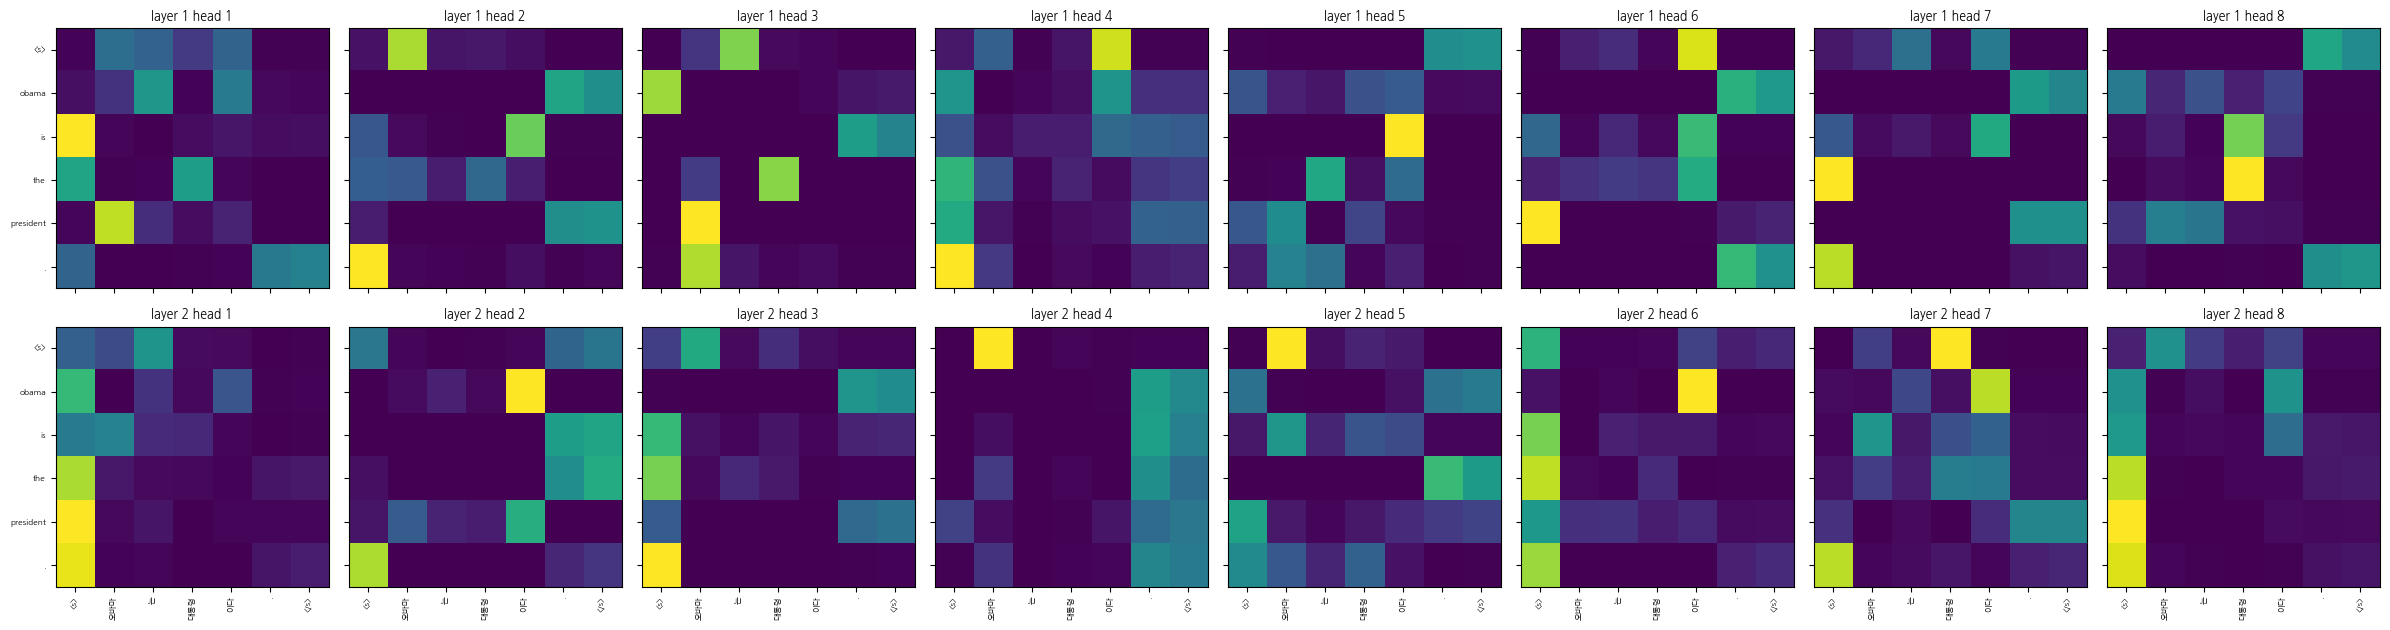

In [27]:
draw_attention("오바마는 대통령이다.")


### 과소적합 모델의 attention 과 비교해 보면

본 학습 전에 돌린 15에폭(과소적합) 모델로 같은 문장의 attention map 을 그려뒀었다 (아래 그림).  
그때는 16장 전부가 세로 줄무늬였다 — 무슨 영어 조각을 만들든 계속 같은 한국어 조각 몇 개만 쳐다본다는 뜻이고,  
그 결과가 "the United States, the United States, ..." 반복이었다. 
반복 붕괴가 attention 차원에서는 세로 줄무늬로 보인다는 것, 그리고 학습이 진행되면 그 줄무늬가 풀리면서 번역이 갈라진다는 것을 눈으로 확인했다.

<img src="images/attention_map_15ep.png" width="900">

읽어낸 것 세 가지.

1. **줄무늬가 풀렸다.** 과소적합 때는 16장 전부 같은 세로줄이었는데, 학습이 진행된 모델은 헤드마다 보는 곳이 갈라진다.  
   헤드가 8개씩 있는 이유(관점의 분업)가 학습이 진행되어야 실제로 나타난다는 게 재밌다 — 덜 배운 모델에서는 8개가 다 같은 걸 본다.  
2. **정렬의 흔적이 보인다.** 문장 첫 영어 조각을 만들 때 한국어 첫 조각을 강하게 보는 헤드, 문장 끝(마침표·EOS)을 계속 주시하는 헤드처럼 역할이 생겼다.  
   다만 한국어는 동사가 문장 끝에 오고 영어는 앞에 와서, 입력과 출력이 순서대로 나란히 대응하는 모양은 안 나온다.  
   처음에는 그림이 지저분해서 잘못된 줄 알았는데, 어순이 다른 두 언어가 나란히 맞아떨어지면 그게 오히려 이상한 것이었다.  
   그렇게 생각하고 다시 보니 같은 그림이 다르게 읽혔다.    
3. **번역이 틀리는 지점과 attention 이 흐린 지점이 겹친다.** 고유명사나 훈련에서 드물던 조각을 만들 때는 attention 이 여러 조각에 흩어지며 번역도 뭉개진다.  
   loss 숫자로는 안 보이는 "모델이 어디서 헤매는가"가 이 그림에서는 위치 단위로 보인다.  

하나 더, 정직하게 적어둘 것: 반복 붕괴가 다 나은 건 아니다. 짧은 문장("오바마는 대통령이다")은 깨끗하게 나오지만,  
위 긴 문장은 60에폭에도 "the second hostages"를 맴돈다.  
다만 15에폭 때 문장과 무관한 "the United States"로 도망가던 것과 달리 지금은 문장의 주제(인질) 안에서 맴돈다 — 절반은 나은 셈이다.  
attention 이 헤드별로 제 역할을 찾은 뒤에도 남는 이 병은 greedy 디코딩(매 토큰 1등만)과 데이터 부족의 몫이고,  
그래서 7절의 beam 실측과 회고의 데이터 확장이 다음 처방이다.


## 9. 회고

- 데이터를 먼저 재보는 습관이 또 값을 했다.  
  94,123쌍이라고 해서 94,123쌍이 아니었다 (16%가 복사본, 같은 쌍이 554번).  
  그리고 중복 제거는 split 전, 증강은 split 뒤 — 방향은 반대지만 원리는 하나다: val 에 train 의 쌍둥이가 들어가면 안 된다.
- subword 는 공짜가 아니다. OOV 를 글자 조각 조립으로 없애는 대신 시퀀스가 두 배 길어진다(단어 14개 -> 토큰 25개).  
  "토큰 50 필터"가 널널해 보였지만 실제로는 95% 지점이었고, 이런 건 재보기 전엔 모른다.
- 과소적합의 지문을 번역기에서 또 만났다. 챗봇의 만능답변("저도 좋은 사람이에요")이 번역기에서는 흔한 뉴스 구절의 반복  
  ("the United States, the United States")으로 나타났고, attention map 에서는 세로 줄무늬로 보였다.  
  같은 병이 과제마다 다른 얼굴로 나온다는 걸 알면, loss 숫자 없이 생성물만 봐도 진단이 된다.  
- 이번에도 노드 코드를 그대로 믿지 않길 잘했다. SentencePiece 인자 문자열 깨짐, 스케줄러 선언 순서, loss 의 transpose 누락 — 셋 다 "돌려보기 전에 읽어서" 잡은 것이 아니라  
  돌려보고 읽어보며 잡은 것이다. 코드는 의미로 판단하지 말고 값을 넣어 추적한다는 NLP02 의 교훈이 그대로 이어졌다.  
- 아쉬운 것: 뉴스 코퍼스 하나로 학습해서 문체 밖 문장('안녕')에는 약하다. 디코딩도 greedy 라서 무난한 구절로 도망가는 경향이 남아 있다.  
  Beam Search 와 다양한 코퍼스가 다음 열쇠다. (beam 은 궁금해서 노트북 밖 사이드 실험으로 실측까지 해봤다 — 7절. 40에폭 체크포인트 기준 greedy 대비 +63%.)
- 되돌아보니 데이터 증강을 좀 더 고려했어야 하지 않았나 싶다.  
  NLP02 챗봇에서는 증강을 했는데, 그건 루브릭이 "3만 개 데이터셋"을 요구해서 한 것이었다.  
  이번에는 아무도 시키지 않으니 그 카드를 떠올리지도 않았다. 병에 따라 꺼낸 게 아니라 시키는 대로 꺼낸 셈이다.  
  더 뼈아픈 건 7절이다. 숫자 환각을 두고 "이건 데이터 부족의 병"이라고 진단해놓고도,  
  개선 순서에는 새 코퍼스를 구해오는 것만 적었지 가진 데이터를 불리는 쪽은 한 줄도 안 적었다.  
  물론 번역 증강이 챗봇 증강의 복사판일 리는 없다. 챗봇은 문장 하나 안에서 단어를 바꿔치기하면 됐지만,  
  번역은 한국어와 영어가 쌍으로 묶여 있어서 한쪽만 건드리면 짝이 어긋난다.  
  NLP02 에서 아쉬워했던 "반의어 치환의 의미 오염"이 여기서는 곧바로 오역이 된다.  
  그래서 번역에는 번역 나름의 증강 방법이 따로 있을 텐데, 이번에는 거기까지 못 봤다. 다음 과제로 남긴다.
- 그럼 증강을 대체 어떻게 하는 건가 싶어 생각을 좀 굴려봤다.  
  처음엔 한영사전 같은 걸로 단어를 바꿔치우면 되는 것 아닌가 했는데, 따져볼수록 그게 잘 안 되는 이유가 쌓였다.  
  같은 단어도 문맥마다 뜻이 달라서 사전은 어느 뜻인지 모르고, 단어끼리 실제로 같이 쓰이는 짝도 따로 있다.  
  무엇보다 말은 쓰이는 자리마다 결이 다르다. 뉴스, 채팅, 공식 석상, 학교, 종교기관에서 쓰는 말이 다 다른데  
  사전은 그 자리를 모른다. NLP02 에서 겪은 반의어 치환 사고가 딱 그 증거였다.  
  임베딩이 가깝다고 뽑아준 단어의 뜻이 정반대였으니까.  
  번역은 여기에 한국어와 영어의 짝 맞추기까지 얹힌다.  
  그래서 번역 쪽에서는 역번역이라는 걸 쓴다고 한다. 영어 문장을 반대 방향 모델로 한국어로 옮겨 가짜 한국어를 만들고,  
  (가짜 한국어, 진짜 영어) 쌍으로 학습하는 것이다. 노이즈가 입력 쪽에만 들어가고 정답 쪽은 사람이 쓴 문장 그대로라  
  짝이 안 깨진다. 다만 그 반대 방향 모델도 내가 만들어야 하는데, 내 번역기가 BLEU 2.26 인 걸 보면  
  그 가짜 한국어가 쓸 만할지는 재봐야 아는 일이다.  
  요즘은 아예 LLM 으로 문장을 불리기도 한다는데, 여기엔 collapse 라는 함정이 있다고 한다.  
  모델이 만든 문장으로 모델을 다시 가르치면 드문 표현이 깎이고 흔한 표현만 남는다는 것이다.  
  그런데 이건 내가 이번에 이미 본 병이다. 챗봇의 만능답변("저도 좋은 사람이에요"),  
  번역기의 "the United States" 반복 — 전부 흔한 쪽으로 도망가는 병이었다.  
  그렇다면 LLM 증강은 이 병을 고치기는커녕 부추길 수도 있다는 뜻이고,  
  "일곱 명"을 "40 people"로 옮기는 숫자 환각도 지어낸 문장으로는 못 고친다. 그건 진짜 문장이 있어야 고쳐진다.  
  결국 증강은 "데이터를 불린다"가 아니라 "무엇은 불릴 수 있고 무엇은 못 불리는가"의 문제였다.  
  여기까지가 지금 내 이해이고, 맞는지는 다음에 증강을 제대로 배우면서 확인해볼 숙제로 남긴다.
